In [1]:
import os, importlib
import sys
sys.path.insert(0, "../Localization")

import mitsuba as mi
print(mi.variants())

# mi.set_variant("llvm_ad_rgb")
mi.set_variant("llvm_ad_mono_polarized")

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, ITURadioMaterial

import sionna

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import util
import plot


['scalar_rgb', 'scalar_spectral', 'scalar_spectral_polarized', 'llvm_ad_rgb', 'llvm_ad_mono', 'llvm_ad_mono_polarized', 'llvm_ad_spectral', 'llvm_ad_spectral_polarized', 'cuda_ad_rgb', 'cuda_ad_mono', 'cuda_ad_mono_polarized', 'cuda_ad_spectral', 'cuda_ad_spectral_polarized']


In [8]:
# Import scene as xml file
scene = load_scene("PropagationConfig1/Propagation.xml")

scene.radio_materials["itu-concrete"].thickness = 0.1

# print("Available materials:", scene.radio_materials.keys())
# mat = scene.radio_materials["itu-concrete"]
# print(f"Material: {mat.name}")
# print(f"Conductivity: {mat.conductivity.numpy()} S/m")
# print(f"Relative Permittivity: {mat.relative_permittivity.numpy()}")
# print(f"Thickness: {mat.thickness.numpy()} m")


scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='iso',
                             polarization='V')

scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern='iso',
                             polarization='V')

print(scene.rx_array.antenna_pattern.compute_gain())

tx = Transmitter("tx", [0, -0.2, 0], display_radius=0.5)
# tx = Transmitter("tx", [-4, 8, 1])
scene.add(tx)

rx1 = Receiver("rx", [0, 0.2, 0], display_radius=0.5)
scene.add(rx1)


scene.preview()

Directivity [dB]: -7.82e-05
Gain [dB]: 0.0
Efficiency [%]: 1e+02
([0.999982], [1], [1.00002])


In [9]:
pathSolver = PathSolver()
paths = pathSolver(scene=scene, max_depth=2)

scene.preview(paths=paths)

(1,)
(1,)
(1,)
1.0
1.0000000000000001e-11


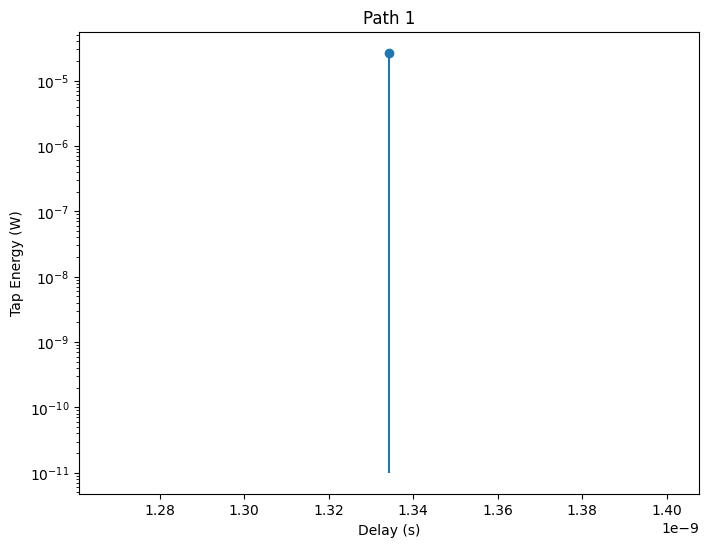

In [10]:
# Channel impulse response of the path
cir = paths.cir(sampling_frequency=3.5e9,
                num_time_steps=1,
                normalize_delays=False)


delays, magnitudes = util.format_cir(cir)
delays = delays[0]
magnitudes = magnitudes[0]
print(delays.shape)
print(magnitudes.shape)

# Energy of paths
energies = magnitudes**2
print(energies.shape)

# Filtering out taps lower than the sensitivity theshold
P_TX_dBm = 30
P_TX_lin = 10 ** (P_TX_dBm / 10) / 1000  # Convert dBm to Watts
print(P_TX_lin)

S_RX_dBm = -80
S_RX_lin = 10 ** (S_RX_dBm / 10) / 1000  # Convert dBm to Watts
print(S_RX_lin)

energies = energies * P_TX_lin
mask = magnitudes >= S_RX_lin
delays = delays[mask]
magnitudes = magnitudes[mask]
energies = energies[mask]



plt.figure(figsize=(8, 6))
plt.stem(delays, energies, bottom=S_RX_lin)
plt.yscale('log')
plt.title(f'Path {1}')
plt.xlabel('Delay (s)')
plt.ylabel('Tap Energy (W)')
# plot.plot_taps(delays, magnitudes)
plt.show()



In [11]:
energy_array = np.zeros(20)

for i in range(20):

    thickness = 0.01 * (i+10)

    scene.radio_materials["itu-concrete"].thickness = thickness

    pathSolver = PathSolver()
    paths = pathSolver(scene=scene, max_depth=2)

    # Channel impulse response of the path
    cir = paths.cir(sampling_frequency=3.5e9,
                    num_time_steps=1,
                    normalize_delays=False)


    delays, magnitudes = util.format_cir(cir)
    delays = delays[0]
    magnitudes = magnitudes[0]

    # Energy of paths
    energies = magnitudes**2

    # Filtering out taps lower than the sensitivity theshold

    energies = energies * P_TX_lin
    mask = magnitudes >= S_RX_lin
    delays = delays[mask]
    magnitudes = magnitudes[mask]
    energies = energies[mask]

    energy_array[i] = energies[0]

    

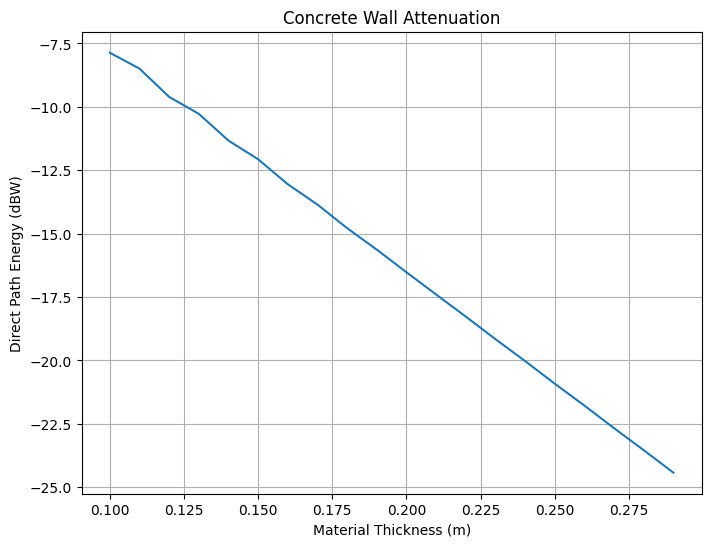

Attenuation slope: -43.02 dB/m
-11.328744212303477 -15.630717610544362


In [12]:
free_loss = 0.0001633383653825149 # For 0.4
# free_loss = 0.0006533534615300596 # For 0.2

plt.figure(figsize=(8, 6))
plt.plot(0.01 * np.arange(10, 30), 10*np.log10(energy_array / free_loss))
plt.title('Concrete Wall Attenuation')
plt.xlabel('Material Thickness (m)')
plt.ylabel('Direct Path Energy (dBW)')
plt.grid()
plt.show()

slope = (10*np.log10(energy_array[9] / free_loss) - 10*np.log10(energy_array[4] / free_loss)) / 0.1
print(f"Attenuation slope: {slope:.2f} dB/m")
print(10*np.log10(energy_array[4] / free_loss), 10*np.log10(energy_array[9] / free_loss))

In [14]:
energy_array = np.zeros(20)
for i in range(20):

    r = 0.1 * (i+1)

    # Import scene as xml file
    scene = load_scene("PropagationConfig1/Propagation.xml")

    scene.radio_materials["itu-concrete"].thickness = 0.1

    # print("Available materials:", scene.radio_materials.keys())
    # mat = scene.radio_materials["itu-concrete"]
    # print(f"Material: {mat.name}")
    # print(f"Conductivity: {mat.conductivity.numpy()} S/m")
    # print(f"Relative Permittivity: {mat.relative_permittivity.numpy()}")
    # print(f"Thickness: {mat.thickness.numpy()} m")


    scene.tx_array = PlanarArray(num_rows=1,
                                num_cols=1,
                                vertical_spacing=0.5,
                                horizontal_spacing=0.5,
                                pattern='dipole',
                                polarization='V')

    scene.rx_array = PlanarArray(num_rows=1,
                                num_cols=1,
                                vertical_spacing=0.5,
                                horizontal_spacing=0.5,
                                pattern='dipole',
                                polarization='V')

    tx = Transmitter("tx", [5, -r, 0])
    # tx = Transmitter("tx", [-4, 8, 1])
    scene.add(tx)

    rx1 = Receiver("rx", [5, r, 0])
    scene.add(rx1)

    pathSolver = PathSolver()
    paths = pathSolver(scene=scene, max_depth=1)

    # Channel impulse response of the path
    cir = paths.cir(sampling_frequency=3.5e9,
                    num_time_steps=1,
                    normalize_delays=False)


    delays, magnitudes = util.format_cir(cir)
    delays = delays[0]
    magnitudes = magnitudes[0]

    # Energy of paths
    energies = magnitudes**2

    # Filtering out taps lower than the sensitivity theshold

    energies = energies * P_TX_lin
    mask = magnitudes >= S_RX_lin
    delays = delays[mask]
    magnitudes = magnitudes[mask]
    energies = energies[mask]

    energy_array[i] = energies[0]

    

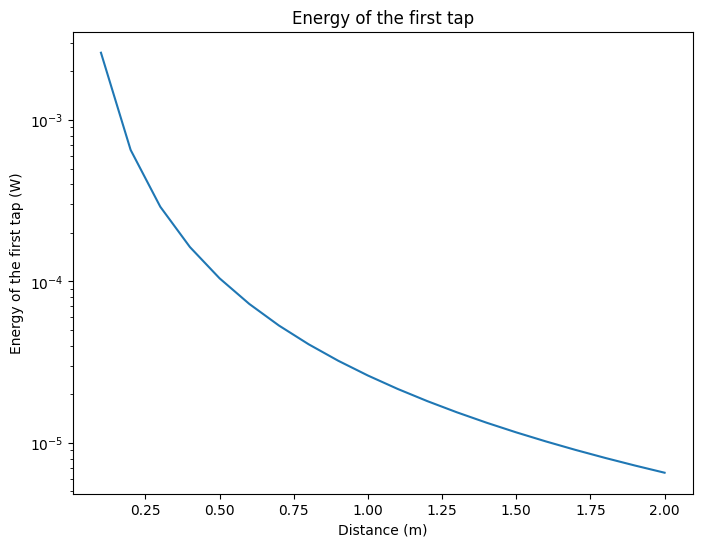

0.0006533534615300596


In [15]:
plt.figure(figsize=(8, 6))
plt.plot(0.1 * np.arange(1, 21), energy_array)
plt.yscale('log')
plt.title('Energy of the first tap')
plt.xlabel('Distance (m)')
plt.ylabel('Energy of the first tap (W)')
plt.show()

print(energy_array[1])

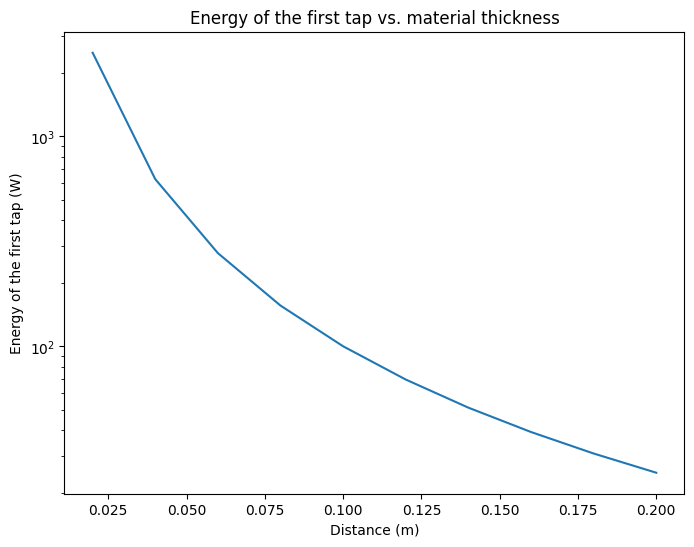

1.0453656315803528e-06


In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(0.02 * np.arange(1, 11), 1/(0.02 * np.arange(1, 11))**2 )
plt.yscale('log')
plt.title('Energy of the first tap vs. material thickness')
plt.xlabel('Distance (m)')
plt.ylabel('Energy of the first tap (W)')
plt.show()

print((energy_array[0]) / (1/0.02**2))